Using Category: VendorID
Using Metric: ContractValue_USD


C:\Users\tanya.DESKTOP-NQGOIC4\AppData\Local\Temp\ipykernel_15656\2936926672.py:65: UserWarning: Glyph 127942 (\N{TROPHY}) missing from current font.
  plt.tight_layout()
c:\Users\tanya.DESKTOP-NQGOIC4\OneDrive\Documents\VendorX\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


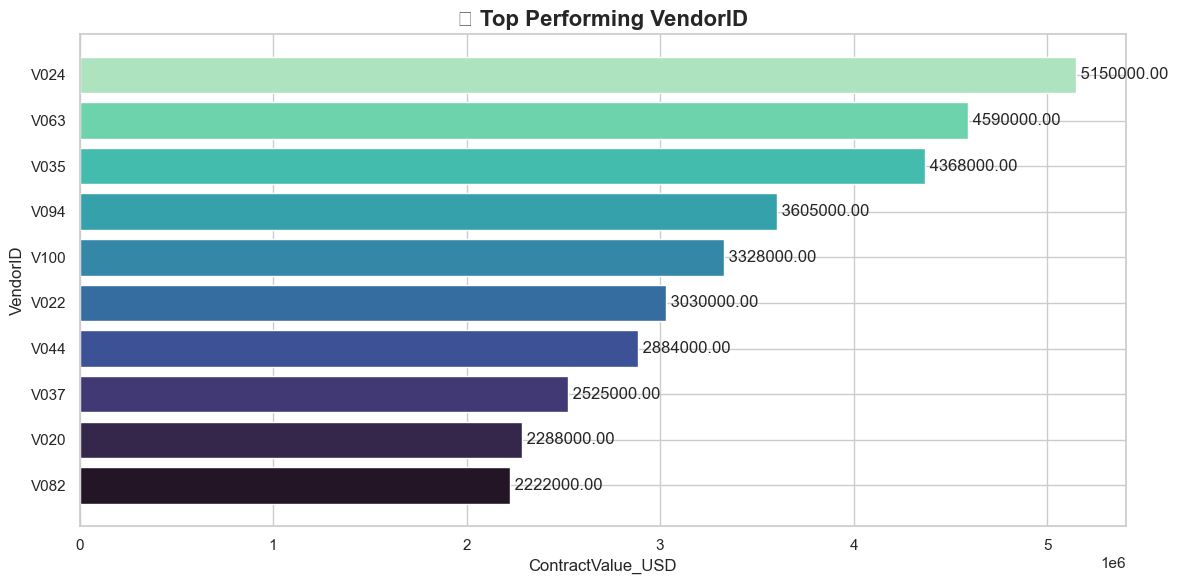

C:\Users\tanya.DESKTOP-NQGOIC4\AppData\Local\Temp\ipykernel_15656\2936926672.py:84: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
c:\Users\tanya.DESKTOP-NQGOIC4\OneDrive\Documents\VendorX\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


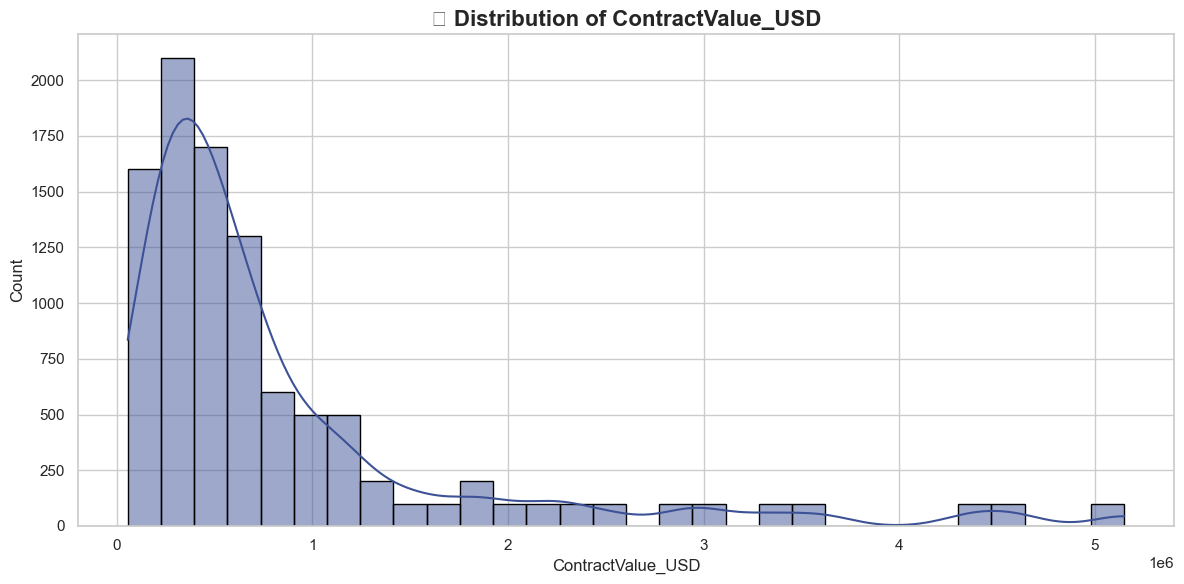

C:\Users\tanya.DESKTOP-NQGOIC4\AppData\Local\Temp\ipykernel_15656\2936926672.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\tanya.DESKTOP-NQGOIC4\AppData\Local\Temp\ipykernel_15656\2936926672.py:102: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from current font.
  plt.tight_layout()
c:\Users\tanya.DESKTOP-NQGOIC4\OneDrive\Documents\VendorX\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


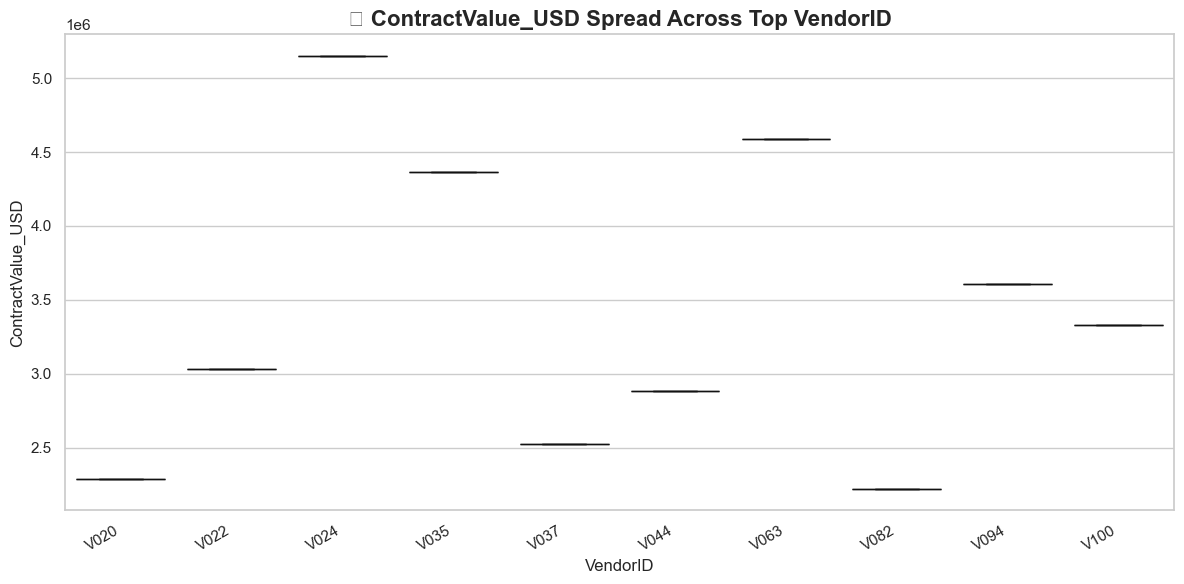

C:\Users\tanya.DESKTOP-NQGOIC4\AppData\Local\Temp\ipykernel_15656\2936926672.py:122: UserWarning: Glyph 128293 (\N{FIRE}) missing from current font.
  plt.tight_layout()
c:\Users\tanya.DESKTOP-NQGOIC4\OneDrive\Documents\VendorX\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


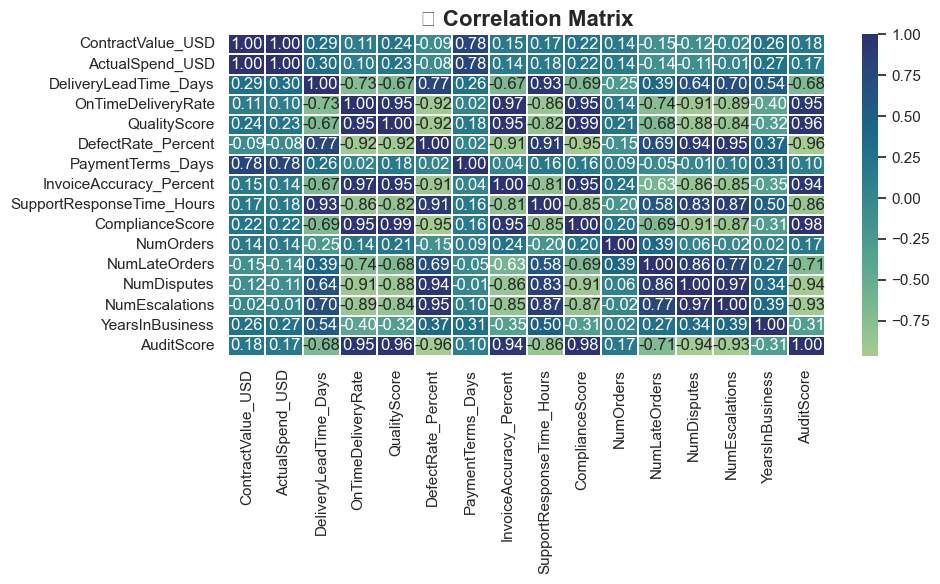

C:\Users\tanya.DESKTOP-NQGOIC4\AppData\Local\Temp\ipykernel_15656\2936926672.py:139: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  plt.tight_layout()
c:\Users\tanya.DESKTOP-NQGOIC4\OneDrive\Documents\VendorX\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


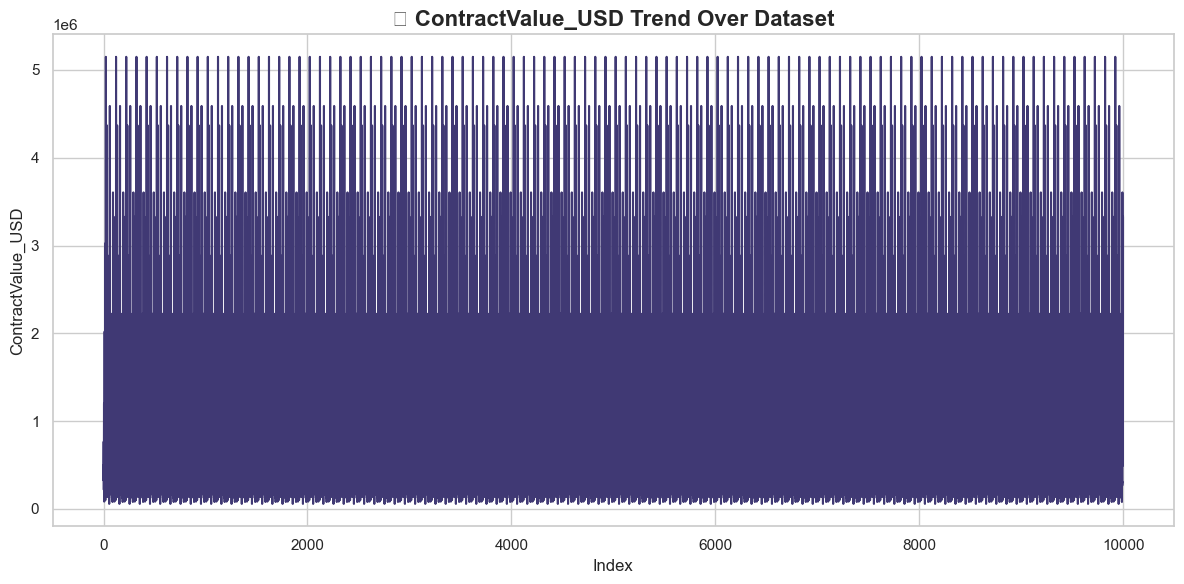

C:\Users\tanya.DESKTOP-NQGOIC4\AppData\Local\Temp\ipykernel_15656\2936926672.py:154: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\tanya.DESKTOP-NQGOIC4\AppData\Local\Temp\ipykernel_15656\2936926672.py:163: UserWarning: Glyph 128640 (\N{ROCKET}) missing from current font.
  plt.tight_layout()
c:\Users\tanya.DESKTOP-NQGOIC4\OneDrive\Documents\VendorX\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128640 (\N{ROCKET}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


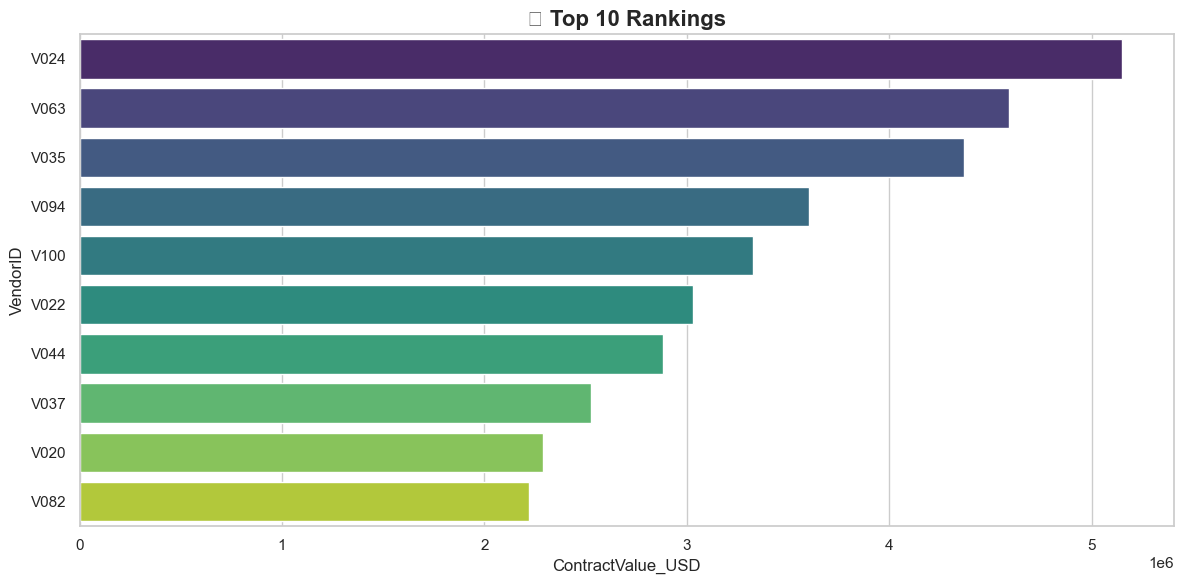


🧠 KEY INSIGHTS
🏆 Best VendorID: V024
⚠️ Lowest VendorID: V082

📊 Average ContractValue_USD: 861920.50
📉 Median ContractValue_USD: 497450.00

📌 Top 5 Performers:
VendorID
V024    5150000.0
V063    4590000.0
V035    4368000.0
V094    3605000.0
V100    3328000.0
Name: ContractValue_USD, dtype: float64


In [21]:
# ==========================================
# 1. IMPORTS & SETUP
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("../data/vendor_data_big.csv")

# Theme
sns.set_theme(style="whitegrid")

# Custom palette
colors = sns.color_palette("mako", 10)

plt.rcParams.update({
    "figure.figsize": (12,6),
    "axes.titlesize": 16,
    "axes.labelsize": 12
})

# ==========================================
# 2. AUTO DETECT COLUMNS
# ==========================================
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()

if len(cat_cols) == 0 or len(num_cols) == 0:
    raise Exception("Dataset must have at least 1 categorical and 1 numeric column")

cat = cat_cols[0]
num = num_cols[0]

print("Using Category:", cat)
print("Using Metric:", num)

# ==========================================
# 3. PREP DATA (TOP 10 CLEAN VIEW)
# ==========================================
top_data = (
    df.groupby(cat)[num]
    .mean()
    .sort_values(ascending=True)
    .tail(10)
    .reset_index()
)

# ==========================================
# 4. AESTHETIC HORIZONTAL BAR CHART
# ==========================================
plt.figure()

bars = plt.barh(top_data[cat], top_data[num], color=colors)

# Value labels
for i, v in enumerate(top_data[num]):
    plt.text(v, i, f" {v:.2f}", va='center')

plt.title(f"🏆 Top Performing {cat}", weight='bold')
plt.xlabel(num)
plt.ylabel(cat)

plt.tight_layout()
plt.show()

# ==========================================
# 5. DISTRIBUTION PLOT (SMOOTH + CLEAN)
# ==========================================
plt.figure()

sns.histplot(
    df[num],
    kde=True,
    color=colors[3],
    edgecolor="black",
    bins=30
)

plt.title(f"📊 Distribution of {num}", weight='bold')
plt.xlabel(num)

plt.tight_layout()
plt.show()

# ==========================================
# 6. BOXPLOT (OUTLIERS + SPREAD)
# ==========================================
plt.figure()

sns.boxplot(
    data=df[df[cat].isin(top_data[cat])],
    x=cat,
    y=num,
    palette="mako"
)

plt.xticks(rotation=30, ha='right')
plt.title(f"📦 {num} Spread Across Top {cat}", weight='bold')

plt.tight_layout()
plt.show()

# ==========================================
# 7. CORRELATION HEATMAP (CLEAN)
# ==========================================
plt.figure(figsize=(10,6))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="crest",
    linewidths=0.3
)

plt.title("🔥 Correlation Matrix", weight='bold')

plt.tight_layout()
plt.show()

# ==========================================
# 8. TREND LINE (SMOOTH FLOW)
# ==========================================
plt.figure()

sns.lineplot(
    x=df.index,
    y=df[num],
    color=colors[2]
)

plt.title(f"📈 {num} Trend Over Dataset", weight='bold')
plt.xlabel("Index")

plt.tight_layout()
plt.show()

# ==========================================
# 9. PREMIUM RANKING BAR (TOP 10)
# ==========================================
ranked = (
    df.groupby(cat)[num]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure()

sns.barplot(
    x=ranked.values,
    y=ranked.index,
    palette="viridis"
)

plt.title("🚀 Top 10 Rankings", weight='bold')
plt.xlabel(num)

plt.tight_layout()
plt.show()

# ==========================================
# 10. SMART INSIGHTS (PRINT)
# ==========================================
print("\n🧠 KEY INSIGHTS")

best = ranked.index[0]
worst = ranked.index[-1]

print(f"🏆 Best {cat}: {best}")
print(f"⚠️ Lowest {cat}: {worst}")

print(f"\n📊 Average {num}: {df[num].mean():.2f}")
print(f"📉 Median {num}: {df[num].median():.2f}")

print("\n📌 Top 5 Performers:")
print(ranked.head())